In [1]:
import numpy as np
import matplotlib.pyplot as plt

n_trials = 10000000
n_friends = 3

arrive = np.random.random((n_trials, n_friends))
depart = arrive + 0.25

e_times = np.column_stack((arrive, depart))
e_labels = np.repeat([[*[1]*n_friends, *[-1]*n_friends]], n_trials, axis=0)
r_ix = np.column_stack([np.arange(n_trials)] * (n_friends*2))
c_ix = np.argsort(e_times, axis=1)
max_n_friends = np.max(np.cumsum(e_labels[r_ix, c_ix], axis=1), axis=1)

v, c = np.unique(max_n_friends, return_counts=True)
for i in range(v.shape[0]):
    print(v[i], c[i] / n_trials)

1 0.1251008
2 0.718945
3 0.1559542


In [59]:
overlaps = np.column_stack([~((arrive[:, f0] > depart[:, f1]) | (arrive[:, f1] > depart[:, f0]))
                            for f0 in range(n_friends-1)
                            for f1 in range(f0+1, n_friends)])
overlaps

array([[False, False,  True],
       [False,  True, False],
       [False, False, False],
       ...,
       [False,  True, False],
       [ True,  True,  True],
       [ True, False,  True]], shape=(10000000, 3))

In [ ]:
filt1 = (arrive[:, 0] >= 0.25) & (arrive[:, 0] <= 0.75)
filt2 = (arrive[:, 1] >= 0.25) & (arrive[:, 1] <= 0.75)

In [65]:
filt3 = (~overlaps[:, 0]) & filt1 & filt2

In [67]:
arrive[filt3]

array([[0.7364869 , 0.27818736, 0.95837909],
       [0.7064296 , 0.31996265, 0.97860064],
       [0.31024795, 0.64782555, 0.43202219],
       ...,
       [0.6135055 , 0.3389191 , 0.48794312],
       [0.40853684, 0.729679  , 0.41869322],
       [0.25832138, 0.69394727, 0.70740664]], shape=(624672, 3))

In [72]:
depart - arrive

array([[0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25],
       ...,
       [0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25]], shape=(10000000, 3))

In [69]:
np.any(overlaps[filt3], axis=1)

array([ True, False,  True, ...,  True,  True,  True], shape=(624672,))

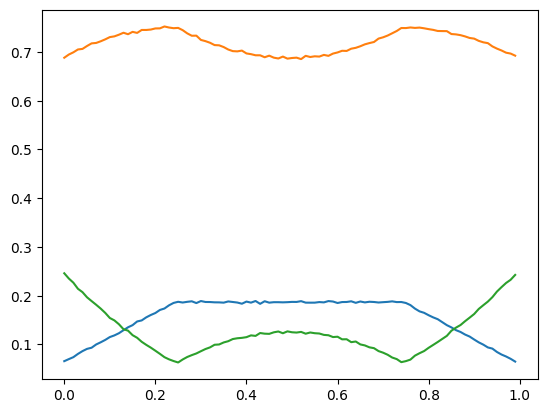

In [60]:
probs3 = []
probs2 = []
probs1 = []
for i in np.arange(0, 1.00, 0.01):
    filt = (arrive[:, 0] >= i) & (arrive[:, 0] < i+0.01)
    # probs += [np.mean(np.sum(overlaps[filt], axis=1) == 0).item()]
    probs3 += [np.mean(max_n_friends[filt] == 3).item()]
    probs2 += [np.mean(max_n_friends[filt] == 2).item()]
    probs1 += [np.mean(max_n_friends[filt] == 1).item()]

plt.plot(np.arange(0, 1.00, 0.01), probs3)
plt.plot(np.arange(0, 1.00, 0.01), probs2)
plt.plot(np.arange(0, 1.00, 0.01), probs1)

plt.show()